# Kozy spatio-temporal graph — exploration

Visualizes the OSM-grounded graph built by `python -m kozy_data build-graph`:
named OSM nodes, road/water edges, the expert causal prior, and event-exposure over time.

In [2]:
import json
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import shape

P = Path('../data/processed')
nodes = pd.read_parquet(P / 'graph_nodes.parquet')
edges = pd.read_parquet(P / 'graph_edges.parquet')
dyn = pd.read_parquet(P / 'graph_dynamic.parquet')
spec = json.loads((P / 'graph_spec.json').read_text())
print(spec['n_nodes'], 'nodes |', spec['n_edges'], '| features:', spec['dynamic_features'])
nodes.head()

86 nodes | {'proximity': 264, 'road': 458, 'water': 31} | features: ['precip_mm', 'snow_mm', 'wind_gust_kmh', 'wind_speed_kmh', 'temp_c', 'humidity_pct', 'pressure_hpa', 'soil_moist', 'flood_warn', 'meteo_warn', 'rcb_alert', 'outage_planned', 'outage_failure']


,node_id,osm_type,osm_id,name,category,value,lat,lon,elevation_m,dist_to_stream_m,dist_to_road_m,height_above_stream_m,building_density,grid_lat,grid_lon
0,n772174143,node,772174143,Chrobacza Łąka,natural,peak,49.822668,19.164980,828.0,166.0,1.5,77.0,0,49.821441,19.155460
1,n772174352,node,772174352,Przełęcz U Panienki,natural,saddle,49.816825,19.151989,739.0,84.3,0.0,17.0,0,49.821441,19.155460
2,n772174436,node,772174436,Gaiki,natural,peak,49.809109,19.123706,816.0,186.6,23.7,71.0,0,49.805907,19.123614
3,n1100451137,node,1100451137,Żródło Maryjne,natural,spring,49.817523,19.154091,678.0,0.0,0.0,0.0,0,49.821441,19.155460
4,n1210543319,node,1210543319,Przegibek,natural,peak,49.795852,19.128689,685.0,290.2,13.2,98.0,0,49.798140,19.131576


## Spatial layout: nodes (by elevation) + road / water edges

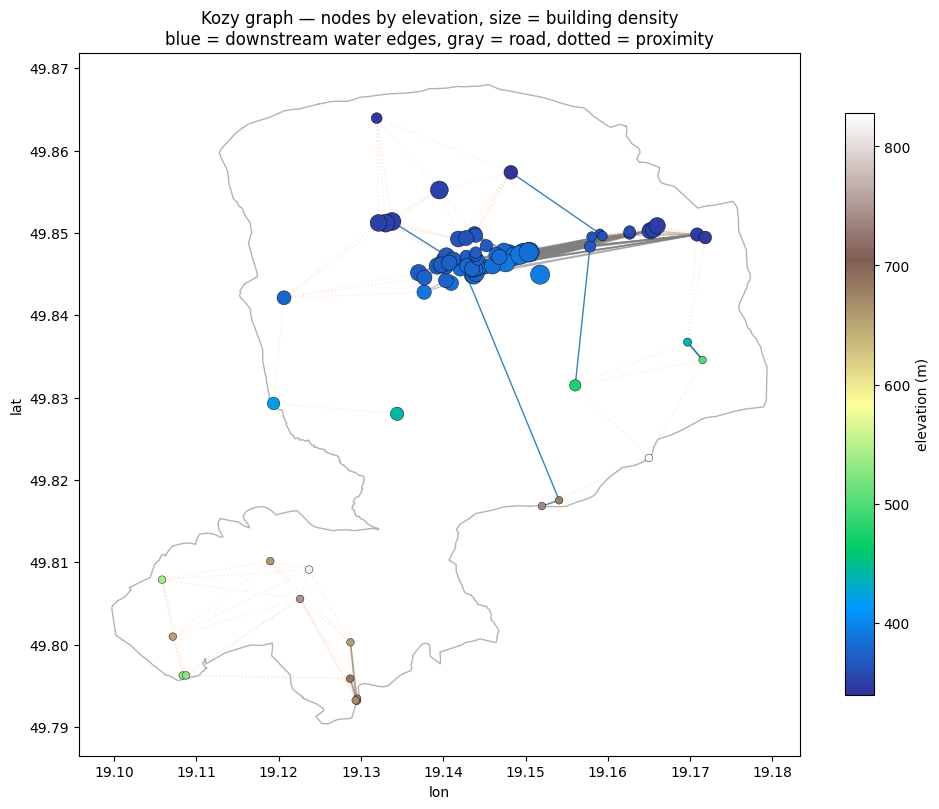

In [3]:
pos = {r.node_id: (r.lon, r.lat) for r in nodes.itertuples()}
fig, ax = plt.subplots(figsize=(10, 10))

# gmina boundary
bnd = json.loads((P / 'kozy_boundary.geojson').read_text())
geom = shape(bnd['features'][0]['geometry'])
for poly in (geom.geoms if geom.geom_type == 'MultiPolygon' else [geom]):
    x, y = poly.exterior.xy
    ax.plot(x, y, color='0.7', lw=1)

styles = {'road': ('tab:gray', 0.4, '-'), 'water': ('tab:blue', 0.9, '-'),
          'proximity': ('tab:orange', 0.15, ':')}
for et, (color, alpha, ls) in styles.items():
    for e in edges[edges.edge_type == et].itertuples():
        if e.src in pos and e.dst in pos:
            (x0, y0), (x1, y1) = pos[e.src], pos[e.dst]
            ax.plot([x0, x1], [y0, y1], color=color, alpha=alpha, ls=ls, lw=1, zorder=1)

sc = ax.scatter(nodes.lon, nodes.lat, c=nodes.elevation_m, cmap='terrain',
                s=30 + nodes.building_density, zorder=3, edgecolor='k', linewidth=0.3)
plt.colorbar(sc, label='elevation (m)', shrink=0.6)
ax.set_title('Kozy graph — nodes by elevation, size = building density\n'
             'blue = downstream water edges, gray = road, dotted = proximity')
ax.set_xlabel('lon'); ax.set_ylabel('lat'); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

## Expert causal prior (dynamic channels)

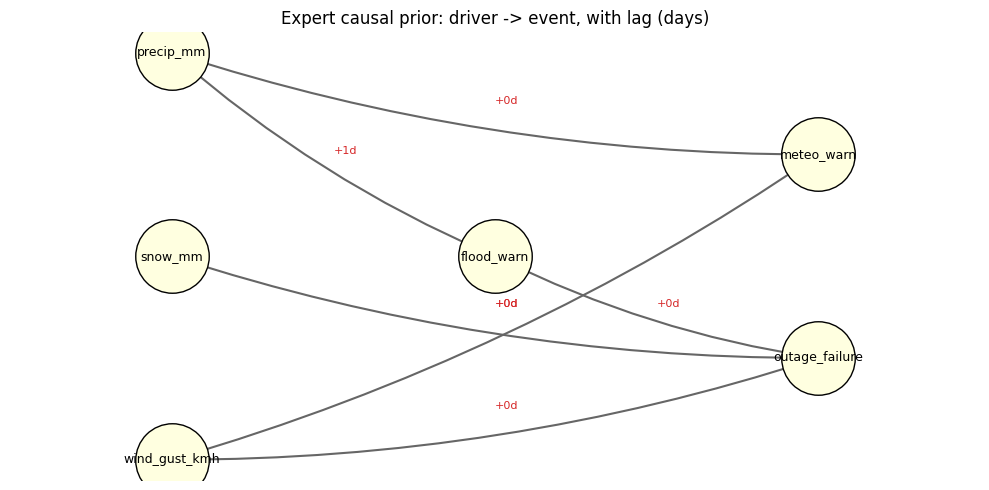

In [4]:
# Small DAG drawn with plain matplotlib (no networkx dependency).
ce = spec['causal_edges']
srcs = {e['src'] for e in ce}
dsts = {e['dst'] for e in ce}
col = {**{n: 0 for n in srcs - dsts},      # pure drivers
       **{n: 1 for n in srcs & dsts},      # intermediate (e.g. flood_warn)
       **{n: 2 for n in dsts - srcs}}      # pure events
bycol = defaultdict(list)
for n, c in col.items():
    bycol[c].append(n)
pos = {}
for c, ns_ in bycol.items():
    for i, n in enumerate(sorted(ns_)):
        pos[n] = (c, -(i - (len(ns_) - 1) / 2))

fig, ax = plt.subplots(figsize=(10, 5))
for e in ce:
    (x0, y0), (x1, y1) = pos[e['src']], pos[e['dst']]
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color='0.4', lw=1.5,
                                connectionstyle='arc3,rad=0.08'))
    ax.text((x0 + x1) / 2, (y0 + y1) / 2, f"+{e['lag_days']}d", fontsize=8, color='tab:red')
for n, (x, y) in pos.items():
    ax.scatter([x], [y], s=2800, color='lightyellow', edgecolor='k', zorder=3)
    ax.text(x, y, n, ha='center', va='center', fontsize=9, zorder=4)
ax.set_title('Expert causal prior: driver -> event, with lag (days)')
ax.set_xlim(-0.5, 2.5); ax.axis('off')
plt.tight_layout(); plt.show()

## Event-exposure timeline (monthly active node-days)

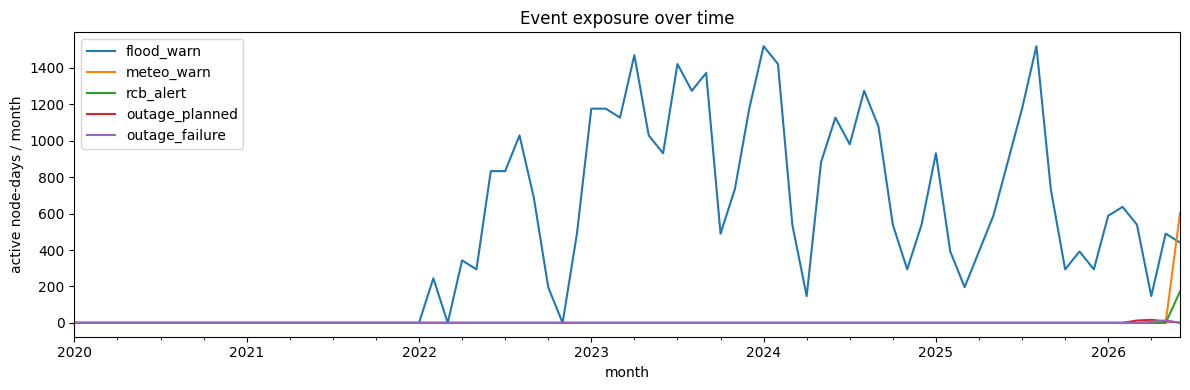

closest-to-stream node: Żródło Maryjne


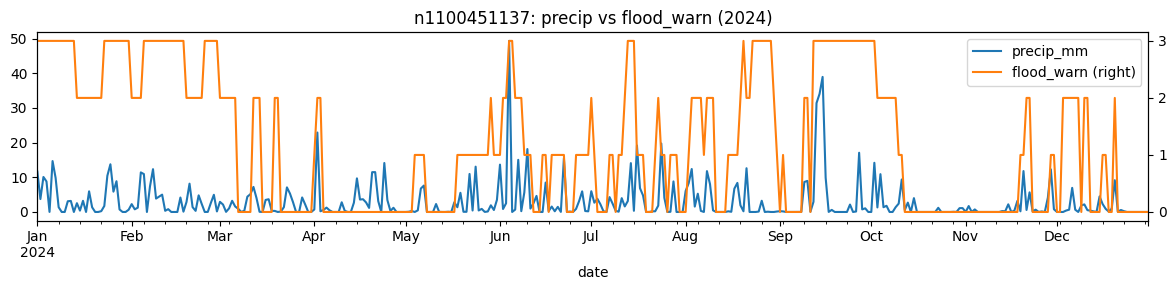

In [5]:
ev = ['flood_warn', 'meteo_warn', 'rcb_alert', 'outage_planned', 'outage_failure']
m = (dyn.assign(month=dyn.date.dt.to_period('M').dt.to_timestamp())
        .groupby('month')[ev].apply(lambda d: (d > 0).sum()))
fig, ax = plt.subplots(figsize=(12, 4))
m.plot(ax=ax)
ax.set_ylabel('active node-days / month'); ax.set_title('Event exposure over time')
plt.tight_layout(); plt.show()

# a single node's driver + event series (sanity check)
nid = nodes.sort_values('dist_to_stream_m').node_id.iloc[0]
s = dyn[dyn.node_id == nid].set_index('date')
print('closest-to-stream node:', nodes.set_index('node_id').loc[nid, 'name'])
s[['precip_mm', 'flood_warn']].loc['2024'].plot(secondary_y='flood_warn', figsize=(12, 3),
    title=f'{nid}: precip vs flood_warn (2024)'); plt.tight_layout(); plt.show()

In [6]:
pd.read_parquet('/home/tomasz/VSC/gnn/data/processed/tauron_outages.parquet')

,timestamp,lat,lon,category,title,url,source,n_streets,spread_km
0,2026-06-12 06:00:00+00:00,49.839623,19.120848,planned,"Kozy ulica Cedrowa, Sadowa, Mieczyków, Krańcow...",https://www.tauron-dystrybucja.pl/wylaczenia,tauron_outages,6,0.969
1,2026-05-29 09:06:38.633000+00:00,49.854489,19.142244,failure,"Kozy ul. Czysta, Świerkowa, Orzechowa, Modrzew...",https://www.tauron-dystrybucja.pl/wylaczenia,tauron_outages,6,0.661
2,2026-05-18 06:00:00+00:00,49.845000,19.142000,planned,"w miejscowości Owczary, przysiółki: Kozylów, O...",https://www.tauron-dystrybucja.pl/wylaczenia,tauron_outages,0,0.000
3,2026-05-12 05:00:00+00:00,49.851093,19.136616,planned,Kozy ulica Jutrzenki na odcinku od ul. Nadbrze...,https://www.tauron-dystrybucja.pl/wylaczenia,tauron_outages,7,0.958
4,2026-04-27 05:00:00+00:00,49.857410,19.138221,planned,"Kozy ulica Przecznia nr 90, 91A,",https://www.tauron-dystrybucja.pl/wylaczenia,tauron_outages,1,0.000
5,2026-04-17 06:00:00+00:00,49.841857,19.166427,planned,"Kozy ulica Podgórska, Słowików, Stokowa, Spoko...",https://www.tauron-dystrybucja.pl/wylaczenia,tauron_outages,4,0.403
6,2026-04-10 06:00:00+00:00,49.841857,19.166427,planned,"Kozy ulica Podgórska, Słowików, Stokowa, Spoko...",https://www.tauron-dystrybucja.pl/wylaczenia,tauron_outages,4,0.403
7,2026-04-08 13:38:04.400000+00:00,49.850967,19.134276,failure,"Kozy ulica Miodowa, Mostowa od nr 19 do ulicy ...",https://www.tauron-dystrybucja.pl/wylaczenia,tauron_outages,10,1.111
8,2026-04-08 08:13:14.573000+00:00,49.850967,19.134276,failure,"Kozy ulica Miodowa, Mostowa od nr 19 do ulicy ...",https://www.tauron-dystrybucja.pl/wylaczenia,tauron_outages,10,1.111
9,2026-04-08 08:00:00+00:00,49.845000,19.142000,planned,"Kozy ulica Sobieskiego nr 103,",https://www.tauron-dystrybucja.pl/wylaczenia,tauron_outages,0,0.000


## Interactive event map (nodes, edges, time slider)

Nodes (coloured by category), road/water/proximity edges, and event exposure over time on one map. Use the layer control (top-right) to toggle layers; water edges animate downstream. Drag the slider or let it auto-play. Adjust `WINDOW` to explore other periods. Also saved as `events_map.html`.

In [7]:
# Interactive map: nodes + edges + event exposure over time (folium time slider).
# Renders inline in Jupyter and also writes a standalone events_map.html.
import folium
from branca.element import Template, MacroElement
from folium.plugins import AntPath, TimestampedGeoJson

aoi_lat, aoi_lon = 49.845, 19.142
# NOTE: meteo/rcb/outage exist only from ~2026; flood from 2022. Default to a window
# where all event types coexist. Widen to e.g. ('2022-01-01','2026-12-31') for flood history.
WINDOW = ('2026-03-01', '2026-06-13')

ninfo = nodes.set_index('node_id')
# unplanned failure (target) is black; planned outage (feature) grey; warnings coloured.
EVENTS = [('outage_failure', '#111111'), ('outage_planned', '#888888'),
          ('flood_warn', '#1f77b4'), ('meteo_warn', '#ff7f0e'),
          ('rcb_alert', '#9467bd')]  # priority order = colour
CAT_COLOUR = {'amenity': '#2ca02c', 'building': '#8c564b', 'natural': '#17becf'}

m = folium.Map(location=[aoi_lat, aoi_lon], zoom_start=13, tiles='cartodbpositron')
folium.GeoJson(json.loads((P / 'kozy_boundary.geojson').read_text()),
               style_function=lambda f: {'color': '#888', 'weight': 1, 'fill': False}).add_to(m)

# --- edge layers (toggleable) ---
fg_road = folium.FeatureGroup(name='edges: road', show=True)
fg_water = folium.FeatureGroup(name='edges: water (downstream)', show=True)
fg_prox = folium.FeatureGroup(name='edges: proximity', show=False)
for e in edges.itertuples():
    if e.src not in ninfo.index or e.dst not in ninfo.index:
        continue
    a, b = ninfo.loc[e.src], ninfo.loc[e.dst]
    line = [[a.lat, a.lon], [b.lat, b.lon]]
    if e.edge_type == 'road':
        folium.PolyLine(line, color='#777', weight=1.5, opacity=0.5).add_to(fg_road)
    elif e.edge_type == 'water':                     # animated arrows flow src->dst = downstream
        AntPath(line, color='#1f77b4', weight=3, opacity=0.9, delay=900).add_to(fg_water)
    else:
        folium.PolyLine(line, color='#ff7f0e', weight=1, opacity=0.35, dash_array='4').add_to(fg_prox)
for fg in (fg_road, fg_water, fg_prox):
    fg.add_to(m)

# --- node layer (toggleable), coloured by category ---
fg_nodes = folium.FeatureGroup(name='OSM nodes', show=True)
for nid, r in ninfo.iterrows():
    folium.CircleMarker(
        [r.lat, r.lon], radius=4, color='#333', weight=0.5, fill=True,
        fill_color=CAT_COLOUR.get(r.category, '#999'), fill_opacity=0.9,
        popup=(f"<b>{r['name']}</b><br>{r.category}/{r.value}<br>"
               f"elev {r.elevation_m:.0f} m | HAND {r.height_above_stream_m:.0f} m<br>"
               f"to stream {r.dist_to_stream_m:.0f} m | density {r.building_density}"),
    ).add_to(fg_nodes)
fg_nodes.add_to(m)

# --- event exposure over time (pulses day by day) ---
win = dyn[(dyn.date >= WINDOW[0]) & (dyn.date <= WINDOW[1])]
active = win[(win[[e for e, _ in EVENTS]] > 0).any(axis=1)]
feats = []
for r in active.itertuples():
    colour, parts = None, []
    for ev, c in EVENTS:
        v = getattr(r, ev)
        if v > 0:
            parts.append(f'{ev}={v:g}')
            colour = colour or c
    nr = ninfo.loc[r.node_id]
    feats.append({
        'type': 'Feature',
        'geometry': {'type': 'Point', 'coordinates': [nr.lon, nr.lat]},
        'properties': {
            'time': pd.Timestamp(r.date).strftime('%Y-%m-%d'),
            'icon': 'circle',
            'iconstyle': {'fillColor': colour, 'fillOpacity': 0.95,
                          'stroke': True, 'color': '#000', 'weight': 1.0, 'radius': 9},
            'popup': f"<b>{nr['name']}</b><br>{'<br>'.join(parts)}",
        },
    })
TimestampedGeoJson({'type': 'FeatureCollection', 'features': feats},
                   period='P1D', duration='P1D', add_last_point=False,
                   transition_time=400, loop=True, auto_play=True,
                   date_options='YYYY-MM-DD').add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
legend_rows = [f'<span style="color:{c}">●</span> event: {e}' for e, c in EVENTS] + \
              [f'<span style="color:{c}">●</span> node: {k}' for k, c in CAT_COLOUR.items()]
legend = ('<div style="position:fixed;bottom:30px;left:10px;z-index:9999;background:white;'
          'padding:6px 10px;border:1px solid #999;font-size:12px">' + '<br>'.join(legend_rows) + '</div>')
mac = MacroElement(); mac._template = Template('{% macro html(this,kwargs) %}' + legend + '{% endmacro %}')
m.get_root().add_child(mac)

m.save('events_map.html')
print(f'{len(feats)} event markers in {WINDOW[0]}..{WINDOW[1]}  |  saved events_map.html')
print('per-event node-days in window:', {e: int((win[e] > 0).sum()) for e, _ in EVENTS})
# m

1981 event markers in 2026-03-01..2026-06-13  |  saved events_map.html
per-event node-days in window: {'outage_failure': 20, 'outage_planned': 40, 'flood_warn': 1617, 'meteo_warn': 602, 'rcb_alert': 172}


## 3D view: graph over terrain

Nodes placed at their real elevation (vertical stems show relief), with road and downstream-water edges. Run `%matplotlib widget` before this cell in Jupyter to rotate/zoom interactively.

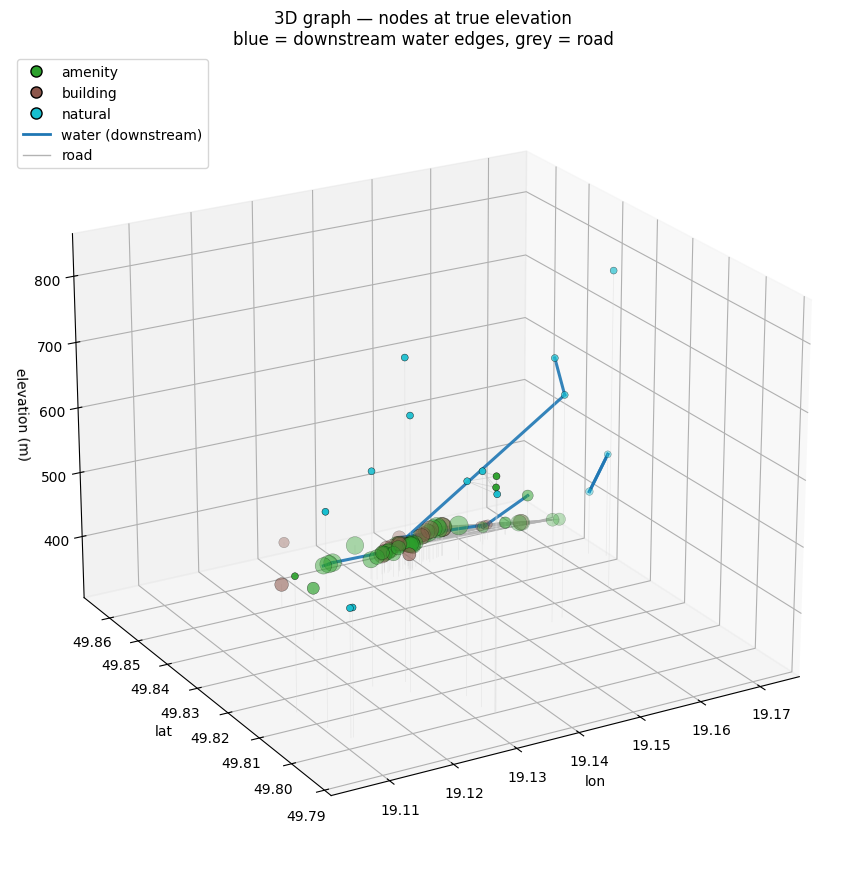

In [8]:
# 3D view: nodes at true elevation + edges. Shows water edges descending the terrain.
# (Static render; in Jupyter run `%matplotlib widget` first to rotate interactively.)
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3d projection)

posz = nodes.set_index('node_id')[['lon', 'lat', 'elevation_m']]
CAT_COLOUR = {'amenity': '#2ca02c', 'building': '#8c564b', 'natural': '#17becf'}

fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection='3d')

# edges (skip proximity to keep it readable)
for e in edges.itertuples():
    if e.src not in posz.index or e.dst not in posz.index:
        continue
    a, b = posz.loc[e.src], posz.loc[e.dst]
    xs, ys, zs = [a.lon, b.lon], [a.lat, b.lat], [a.elevation_m, b.elevation_m]
    if e.edge_type == 'road':
        ax.plot(xs, ys, zs, color='0.7', lw=0.6, alpha=0.4)
    elif e.edge_type == 'water':
        ax.plot(xs, ys, zs, color='tab:blue', lw=2.2, alpha=0.9)

# vertical stems to the base plane emphasise relief
zmin = nodes.elevation_m.min()
for r in nodes.itertuples():
    ax.plot([r.lon, r.lon], [r.lat, r.lat], [zmin, r.elevation_m],
            color='0.85', lw=0.5, alpha=0.5)

ax.scatter(nodes.lon, nodes.lat, nodes.elevation_m,
           c=nodes.category.map(CAT_COLOUR), s=25 + nodes.building_density,
           edgecolor='k', linewidth=0.3, depthshade=True)

ax.set_xlabel('lon'); ax.set_ylabel('lat'); ax.set_zlabel('elevation (m)')
ax.set_title('3D graph — nodes at true elevation\nblue = downstream water edges, grey = road')
ax.view_init(elev=22, azim=-120)
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                  markeredgecolor='k', label=k, markersize=8) for k, c in CAT_COLOUR.items()]
handles += [Line2D([0], [0], color='tab:blue', lw=2, label='water (downstream)'),
            Line2D([0], [0], color='0.7', lw=1, label='road')]
ax.legend(handles=handles, loc='upper left')
plt.tight_layout(); plt.show()

## Training dataset (`build-dataset`)

`python -m kozy_data build-dataset` writes two **inductive** snapshots:
`dataset_train.npz` (sparse graph, dates `< cutoff`) and `dataset_test.npz`
(denser graph adding `shop`, future dates `>= cutoff`). The model must generalize to
**unseen nodes and unseen time**.

- **Target `Y`** `[T, N, C]` — multi-channel forecast *"event active within the next H days"*
  over `[flood_warn, meteo_warn, rcb_alert, outage_failure]`. This matches the project goal
  (cascades of dangerous events) and avoids hinging on the rare failures alone.
- **Features `X`** `[T, N, F]` — every dynamic channel: weather (IDW-interpolated per node +
  elevation lapse-rate), `outage_planned` (scheduled maintenance = explanatory feature), and
  the past event channels (autoregressive).

**Reality check (printed below):** `outage_failure` is sparse (Tauron data is 2026-only) and
`meteo_warn`/`rcb_alert` have no pre-June-2026 history, so the train split shows 0 positives
there — the bundle is correct scaffolding that gains signal as events accumulate forward.
`flood_warn` (history to 2022) is dense in both splits.

In [9]:
import numpy as np

spec = json.loads((P / 'dataset_spec.json').read_text())
tr = np.load(P / 'dataset_train.npz')
te = np.load(P / 'dataset_test.npz')

print('cutoff', spec['cutoff'], '| horizon', spec['horizon_days'], 'd | window', spec['window_days'], 'd')
print('features (X):', list(tr['feature_names']))
print('targets  (Y):', list(tr['target_names']))

# Shapes + per-channel positive labels per split (the reality check).
rows = []
for name, b in [('train (past)', tr), ('test (future)', te)]:
    pos = {c: int((b['Y'][..., i] > 0).sum()) for i, c in enumerate(b['target_names'])}
    rows.append({'split': name, 'T': b['X'].shape[0], 'N': b['X'].shape[1],
                 'dates': f"{str(b['date_index'][0])[:10]}..{str(b['date_index'][-1])[:10]}", **pos})
pd.DataFrame(rows).set_index('split')

cutoff 2026-05-01 | horizon 3 d | window 14 d
features (X): [np.str_('precip_mm'), np.str_('snow_mm'), np.str_('wind_gust_kmh'), np.str_('wind_speed_kmh'), np.str_('temp_c'), np.str_('humidity_pct'), np.str_('pressure_hpa'), np.str_('soil_moist'), np.str_('flood_warn'), np.str_('meteo_warn'), np.str_('rcb_alert'), np.str_('outage_planned'), np.str_('outage_failure')]
targets  (Y): [np.str_('flood_warn'), np.str_('meteo_warn'), np.str_('rcb_alert'), np.str_('outage_failure')]


,T,N,dates,flood_warn,meteo_warn,rcb_alert,outage_failure
split,,,,,,,
train (past),2312,86,2020-01-01..2026-04-30,48020,0,0,18
test (future),45,141,2026-05-01..2026-06-14,1792,1833,846,93


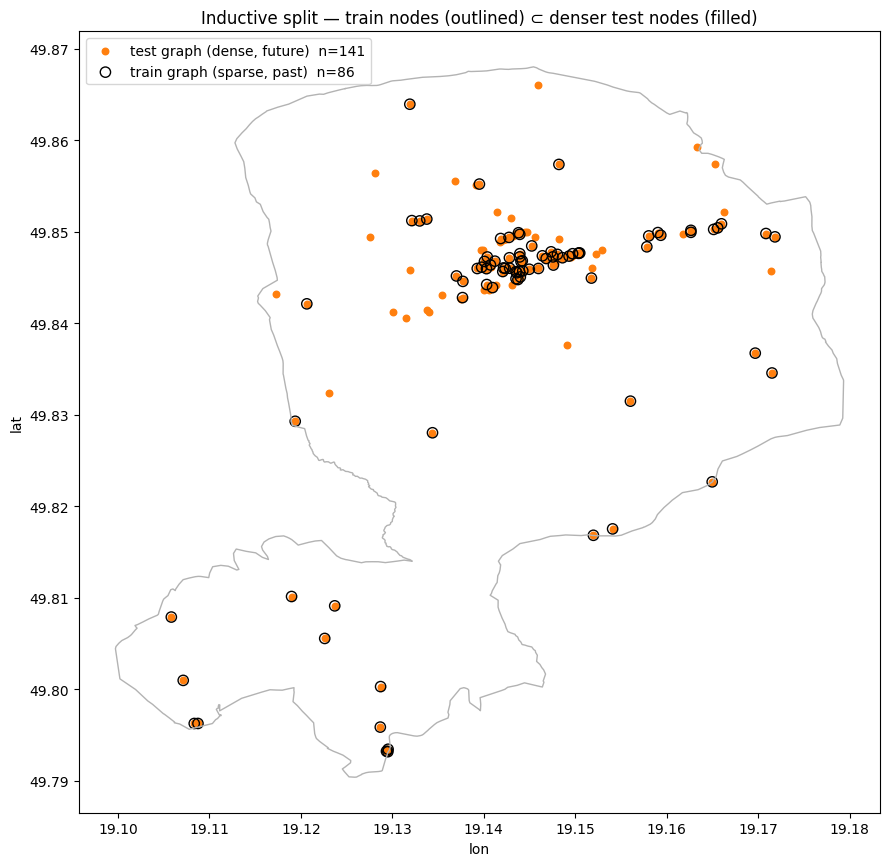

In [10]:
# Spatial split: sparse train graph (past) vs denser test graph (+shop, future).
tr_nodes = pd.read_parquet(P / 'train_graph_nodes.parquet')
te_nodes = pd.read_parquet(P / 'test_graph_nodes.parquet')

fig, ax = plt.subplots(figsize=(9, 9))
bnd = json.loads((P / 'kozy_boundary.geojson').read_text())
geom = shape(bnd['features'][0]['geometry'])
for poly in (geom.geoms if geom.geom_type == 'MultiPolygon' else [geom]):
    ax.plot(*poly.exterior.xy, color='0.7', lw=1)
ax.scatter(te_nodes.lon, te_nodes.lat, s=22, c='tab:orange',
           label=f'test graph (dense, future)  n={len(te_nodes)}')
ax.scatter(tr_nodes.lon, tr_nodes.lat, s=55, facecolor='none', edgecolor='k',
           label=f'train graph (sparse, past)  n={len(tr_nodes)}')
ax.set_title('Inductive split — train nodes (outlined) ⊂ denser test nodes (filled)')
ax.set_xlabel('lon'); ax.set_ylabel('lat'); ax.set_aspect('equal'); ax.legend()
plt.tight_layout(); plt.show()

In [11]:
# One spatio-temporal training sample = a window of past days -> forecast target.
# (kozy_data.dataset.make_windows yields these lazily; inlined here to avoid import setup.)
L = spec['window_days']; t = L - 1
x_win = tr['X'][t - L + 1: t + 1]          # [L, N, F] input window
y_t = tr['Y'][t]                           # [N, C] events within next H days after t
print('sample: x', x_win.shape, '= [L, N, F]  |  y', y_t.shape, '= [N, C]')
print('window ends', str(tr['date_index'][t])[:10], '| target positives:', int((y_t > 0).sum()))

# Optional: wrap one snapshot into a torch_geometric Data (only if torch is installed;
# the bundle itself is framework-agnostic numpy).
try:
    import torch
    from torch_geometric.data import Data
    ei = torch.tensor(np.concatenate([tr['edge_index_proximity'], tr['edge_index_road'],
                                      tr['edge_index_water']], axis=1), dtype=torch.long)
    data = Data(x=torch.tensor(tr['X'][t], dtype=torch.float), edge_index=ei,
                y=torch.tensor(y_t, dtype=torch.float))
    print('PyG Data:', data)
except ImportError:
    print('torch_geometric not installed — skipping PyG adapter (bundle is framework-agnostic).')

sample: x (14, 86, 13) = [L, N, F]  |  y (86, 4) = [N, C]
window ends 2020-01-14 | target positives: 0


/home/tomasz/VSC/gnn/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyG Data: Data(x=[86, 13], edge_index=[2, 753], y=[86, 4])
